In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import bundle_adjust
import glob
import json
import rpcm
import sys
import cv2
from tqdm import tqdm
from PIL import Image
import time

sys.path.insert(0,'..')
print("ok")

ok


In [3]:
from bundle_adjust.cam_utils import SatelliteImage
from bundle_adjust.feature_tracks.ft_classifier import classify_challenging_pairs_SSIM
from bundle_adjust.feature_tracks.ft_opencv import opencv_detect_SIFT, opencv_match_SIFT
from bundle_adjust.feature_tracks.ft_classifier import *
from bundle_adjust import loader


def compute_sift_match_counts(image_i, image_j):
    max_kps = 10000
    tracks_config = {"FT_kp_max": max_kps}
    features_i, n_kp = opencv_detect_SIFT(image_i.geotiff_path, tracks_config=tracks_config)
    features_j, n_kp = opencv_detect_SIFT(image_j.geotiff_path, tracks_config=tracks_config)
    _, _, n_matches_after_ransac = opencv_match_SIFT(features_i, features_j, dst_thr=0.8, ransac_thr=0.3, matcher="flann")
    return n_matches_after_ransac

def pipeline_classifier(
    images,
    pairs_to_match = None,
):
    start_time = time.time()

    if pairs_to_match is None:
        pairs_to_match = []
        for i in np.arange(n_images):
            for j in np.arange(i + 1, n_images):
                if j > i:
                    pairs_to_match.append((i, j))
    print(f"{len(pairs_to_match)} possible pairs")
    
    ds_images = prepare_image_collection_for_SSIM(images, 256)
    
    rows = []
    for pair in tqdm(pairs_to_match):
        j, j = pair[0], pair[1]
        ssim_value = compute_SSIM(ds_images[i], ds_images[j])
        n_matches = compute_sift_match_counts(images[i], images[j])

        rows.append({
            "id_0": i,
            "id_1": j,
            "ssim": ssim_value,
            "sift_matches_ransac": n_matches
        })

    total_time = time.time() - start_time
    return rows, total_time


IMAGES_TO_IGNORE = {
    "JAX": ["6", "8", "9"],
    "UCSD": ["30", "31", "7"],
    "OMA": ["12"]
}

aoi_id = "OMA_177"
img_dir = "/home/roger/BundleAdjustementClassifier/DATA/OMA_177/images_pngs"
myimages = sorted(glob.glob(f"{img_dir}/*.png"))
myimages = [im for im in myimages if os.path.basename(im).split("_")[-2].split(".")[0] not in IMAGES_TO_IGNORE.get(aoi_id.split("_")[0], [])]
input_images = [SatelliteImage(p, None) for p in myimages]
n_images = len(input_images)
rows, total_time = pipeline_classifier(input_images)

csv_path = "/home/roger/BundleAdjustementClassifier/DATA/logs_roger2/ssim_vs_sift.csv"
save_rows_to_csv(rows, csv_path)
rows_ssim_vs_sift = load_rows_from_csv(csv_path)
print(f"Computed in {total_time:.2f} s")

861 possible pairs


  5%|██████▉                                                                                                                                           | 41/861 [00:41<13:58,  1.02s/it]

  9%|█████████████▋                                                                                                                                    | 81/861 [01:20<13:04,  1.01s/it]

 14%|████████████████████▏                                                                                                                            | 120/861 [01:59<12:47,  1.04s/it]

 18%|██████████████████████████▌                                                                                                                      | 158/861 [02:37<11:45,  1.00s/it]

...

 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉ | 855/861 [13:58<00:06,  1.01s/it]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 858/861 [14:01<00:03,  1.03s/it]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 860/861 [14:03<00:01,  1.03s/it]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 861/861 [14:04<00:00,  1.02it/s]

Computed in 844.95 s


Kept pairs: 135/859 (15.72%)


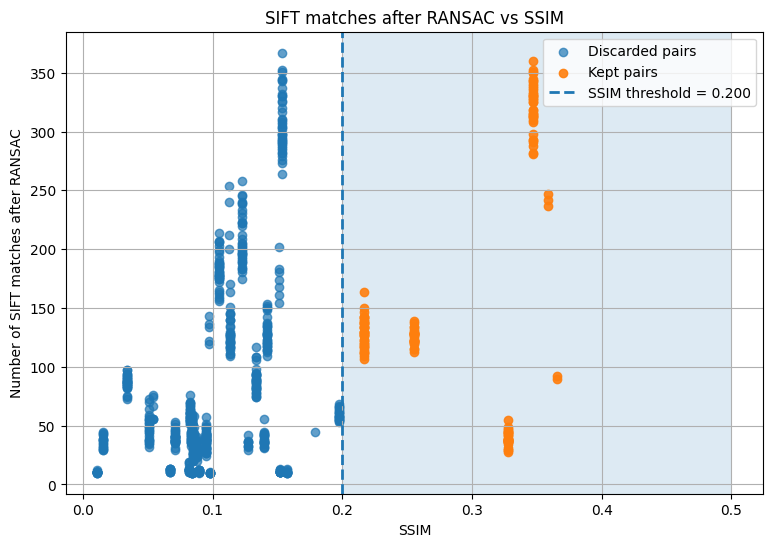

135

In [38]:
def plot_ssim_vs_sift_matches(rows, ssim_threshold=0.70):
    
    y = [row["sift_matches_ransac"] for row in rows if float(row["ssim"]) < 1.0]
    y_label = "Number of SIFT matches after RANSAC"
    title = "SIFT matches after RANSAC vs SSIM"

    x = [row["ssim"] for row in rows if float(row["ssim"]) < 1.0]

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    kept_mask = x >= ssim_threshold
    num_kept = int(np.sum(kept_mask))
    num_total = len(rows)

    plt.figure(figsize=(9, 6))

    # Background green region for kept pairs
    x_max = 0.5 # max(1.0, float(np.max(x)) if len(x) > 0 else 1.0)
    plt.axvspan(ssim_threshold, x_max, alpha=0.15)

    # Scatter points
    plt.scatter(x[~kept_mask], y[~kept_mask], alpha=0.7, label="Discarded pairs")
    plt.scatter(x[kept_mask], y[kept_mask], alpha=0.9, label="Kept pairs")

    # Threshold line
    plt.axvline(ssim_threshold, linestyle="--", linewidth=2, label=f"SSIM threshold = {ssim_threshold:.3f}")

    plt.xlabel("SSIM")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()

    print(f"Kept pairs: {num_kept}/{num_total} ({100.0 * num_kept / max(1, num_total):.2f}%)")
    plt.show()

    return num_kept

csv_path = "/home/roger/BundleAdjustementClassifier/DATA/ssim_vs_sift.csv"
save_rows_to_csv(rows, csv_path)
rows_ssim_vs_sift = load_rows_from_csv(csv_path)
plot_ssim_vs_sift_matches(rows_ssim_vs_sift, ssim_threshold=0.2)

In [27]:
import csv

def _to_python_scalar(x):
    """
    Convert numpy scalars to plain Python scalars so CSV contains normal values,
    e.g. np.int64 -> int.
    """
    if isinstance(x, np.generic):
        return x.item()
    return x

def save_rows_to_csv(rows, csv_path):
    """
    Saves list[dict] -> CSV.

    Assumptions:
    - rows is a flat list of dicts
    - values are scalar-like (int/float/str/bool or numpy scalar versions of those)
    - np.int64 becomes a normal integer in the CSV
    """
    if len(rows) == 0:
        raise ValueError("rows is empty")

    fieldnames = list(rows[0].keys())

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for row in rows:
            clean_row = {k: _to_python_scalar(v) for k, v in row.items()}
            writer.writerow(clean_row)


def load_rows_from_csv(csv_path, schema=None):
    """
    Reads CSV back into list[dict].

    Parameters
    ----------
    schema : dict or None
        Optional mapping column_name -> callable, e.g.
        {
            "id_0": int,
            "id_1": int,
            "cosine_similarity": float,
            "cosine_distance": float,
            "sift_matches_ransac": int,
        }

    Returns
    -------
    rows : list[dict]
    """
    rows = []
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if schema is not None:
                parsed = {}
                for k, v in row.items():
                    if k in schema and v != "":
                        parsed[k] = schema[k](v)
                    else:
                        parsed[k] = v
                row = parsed
            rows.append(row)

    return rows